In [2]:
import pandas as pd
import numpy as np
df=pd.read_csv('diabetes.csv')

#printing first 5 rows
print('First 5 rows')
print(df.head())

#printing shape or dimension of the dataset
print('\ndimension of dataset')
print(df.shape)

#printing columns name in the dataset 
print('\ncolumns names in the dataset :')
print(df.columns.tolist())

# Data type of each column 
print('\nData type of each column :')
print(df.dtypes)

# finding any missing values 
print('\nfinding any missing values :')
print(df.isnull().sum())

# Basic statistics
print("\nBasic Statistics")
print(df.describe())

First 5 rows
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

dimension of dataset
(768, 9)

columns names in the dataset :
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data type of each column :
Pregnancies                   int64
Glucose                       int64
Bl

In [3]:
print(" Diabetes Count :")
print(df['Outcome'].value_counts())

print("\n Percentage :")
print(df['Outcome'].value_counts(normalize=True) * 100)

 Diabetes Count :
Outcome
0    500
1    268
Name: count, dtype: int64

 Percentage :
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


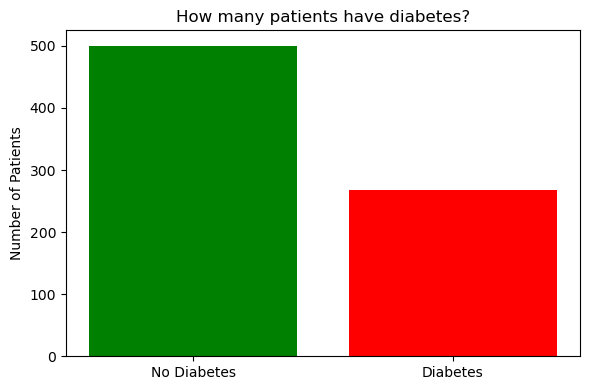

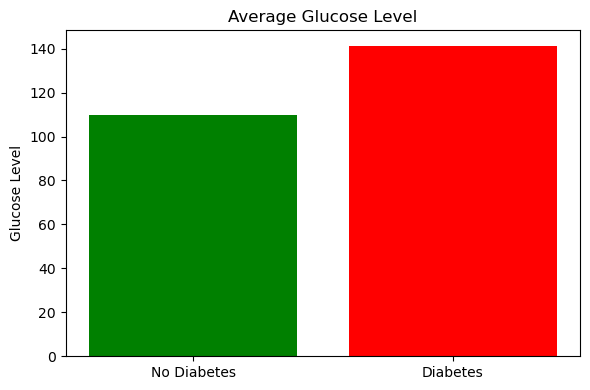

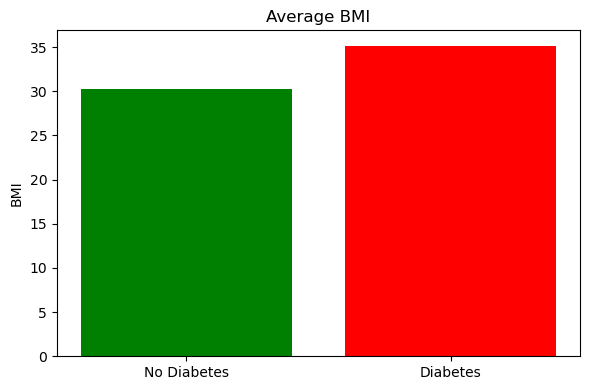

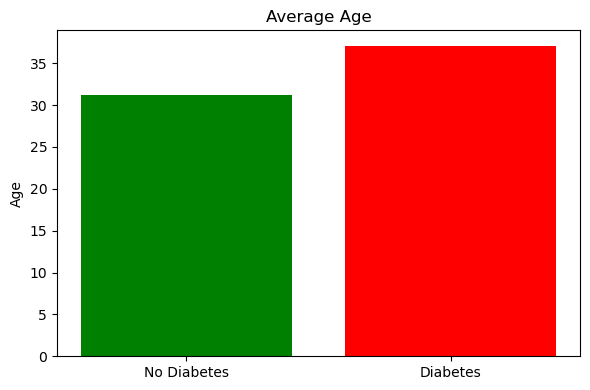

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1 - Diabetes Count (Bar Chart)
plt.figure(figsize=(6,4))
plt.bar(['No Diabetes', 'Diabetes'], 
        [500, 268], 
        color=['green', 'red'])
plt.title('How many patients have diabetes?')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

# Plot 2 - Average Glucose Level
plt.figure(figsize=(6,4))
avg_glucose = df.groupby('Outcome')['Glucose'].mean()
plt.bar(['No Diabetes', 'Diabetes'], 
        avg_glucose, 
        color=['green', 'red'])
plt.title('Average Glucose Level')
plt.ylabel('Glucose Level')
plt.tight_layout()
plt.show()

# Plot 3 - Average BMI
plt.figure(figsize=(6,4))
avg_bmi = df.groupby('Outcome')['BMI'].mean()
plt.bar(['No Diabetes', 'Diabetes'], 
        avg_bmi, 
        color=['green', 'red'])
plt.title('Average BMI')
plt.ylabel('BMI')
plt.tight_layout()
plt.show()

# Plot 4 - Average Age
plt.figure(figsize=(6,4))
avg_age = df.groupby('Outcome')['Age'].mean()
plt.bar(['No Diabetes', 'Diabetes'], 
        avg_age, 
        color=['green', 'red'])
plt.title('Average Age')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

In [5]:
# The columns cannot have 0 as a real value
columns_with_zero=['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('Number of zeros in each column :')
for cols in columns_with_zero:
    zeros=(df[cols]==0).sum()
    print(f"{cols}: {zeros} zeros")

Number of zeros in each column :
Glucose: 5 zeros
BloodPressure: 35 zeros
SkinThickness: 227 zeros
Insulin: 374 zeros
BMI: 11 zeros


In [6]:
# Make a clean copy
df_clean = df.copy()

# Drop columns with too many zeros
df_clean = df_clean.drop(columns=['Insulin', 'SkinThickness'])
print("Dropped Insulin and SkinThickness columns")

# Replace zeros with mean in remaining columns
columns_to_fix = ['Glucose', 'BloodPressure', 'BMI']

for col in columns_to_fix:
    mean_value = df_clean[col].replace(0, np.nan).mean()
    df_clean[col] = df_clean[col].replace(0, mean_value)
    print(f"{col}: zeros replaced with average {mean_value:.2f}")

# Verify no zeros remain
print("\n Zeros remaining :")
for col in columns_to_fix:
    zeros = (df_clean[col] == 0).sum()
    print(f"{col}: {zeros} zeros")

# Check new shape
print(f"\n New dataset shape :")
print(df_clean.shape)
print("\nColumns remaining :")
print(df_clean.columns.tolist())

Dropped Insulin and SkinThickness columns
Glucose: zeros replaced with average 121.69
BloodPressure: zeros replaced with average 72.41
BMI: zeros replaced with average 32.46

 Zeros remaining :
Glucose: 0 zeros
BloodPressure: 0 zeros
BMI: 0 zeros

 New dataset shape :
(768, 7)

Columns remaining :
['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [7]:
#  inputs or parameters
X = df_clean.drop(columns=['Outcome'])

#  Outcome or  what to predict
y = df_clean['Outcome']

print("Input features (X) :")
print(X.shape)
print(X.columns.tolist())

print("\n Target (y) :")
print(y.shape)
print(y.value_counts())

Input features (X) :
(768, 6)
['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']

 Target (y) :
(768,)
Outcome
0    500
1    268
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42     )

print(" Training set size :")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\n Testing set size :")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

 Training set size :
X_train: (614, 6)
y_train: (614,)

 Testing set size :
X_test: (154, 6)
y_test: (154,)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Scaling done!")
print(f"Training set: {X_train_scaled.shape}")
print(f"Testing set: {X_test_scaled.shape}")

 Scaling done!
Training set: (614, 6)
Testing set: (154, 6)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#  Comparing multiple models to find the best performer
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

# Train and test each model
results = {}
for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Test the model
    y_pred = model.predict(X_test_scaled)
    
    # Check accuracy
    accuracy = accuracy_score(y_test, y_pred) * 100
    results[name] = accuracy
    print(f"{name}: {accuracy:.2f}% accuracy")

Logistic Regression: 75.32% accuracy
Random Forest: 77.27% accuracy
KNN: 75.97% accuracy


In [11]:
from sklearn.metrics import classification_report, confusion_matrix

# Use our winning model
best_model = RandomForestClassifier(random_state=42, n_estimators=100)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

# Detailed results
print(" Detailed Report :")
print(classification_report(y_test, y_pred, 
      target_names=['No Diabetes', 'Diabetes']))

 Detailed Report :
              precision    recall  f1-score   support

 No Diabetes       0.83      0.82      0.82        99
    Diabetes       0.68      0.69      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



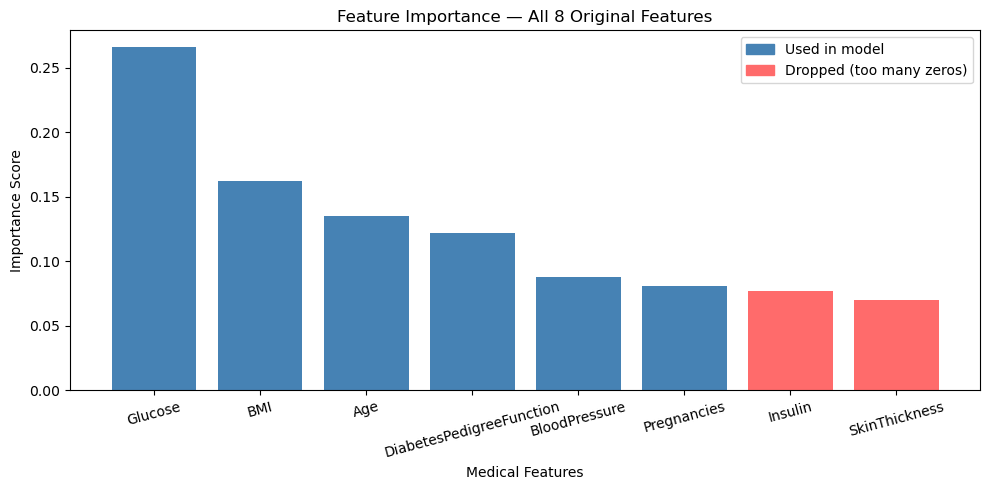

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Train a temporary model with ALL 8 original features
from sklearn.ensemble import RandomForestClassifier

# Use original df with all columns except Outcome
X_all = df.copy()

# Replace zeros with mean for visualization
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    X_all[col] = X_all[col].replace(0, X_all[col].mean())

X_all = X_all.drop(columns=['Outcome'])
y_all = df['Outcome']

# Train temporary model on all features
temp_model = RandomForestClassifier(random_state=42, n_estimators=100)
temp_model.fit(X_all, y_all)

# Get importance of all 8 features
feature_names_all = X_all.columns.tolist()
importances_all = temp_model.feature_importances_

# Sort from most to least important
indices = np.argsort(importances_all)[::-1]
sorted_features = [feature_names_all[i] for i in indices]
sorted_importances = [importances_all[i] for i in indices]

# Color dropped columns differently
colors = []
for f in sorted_features:
    if f in ['Insulin', 'SkinThickness']:
        colors.append('#ff6b6b')   # red = dropped columns
    else:
        colors.append('steelblue') # blue = kept columns

# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(sorted_features, sorted_importances, color=colors)
plt.title('Feature Importance — All 8 Original Features')
plt.xlabel('Medical Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=15)

# Add a legend
import matplotlib.patches as mpatches
blue_patch = mpatches.Patch(color='steelblue', label='Used in model')
red_patch = mpatches.Patch(color='#ff6b6b', label='Dropped (too many zeros)')
plt.legend(handles=[blue_patch, red_patch])

plt.tight_layout()
plt.show()

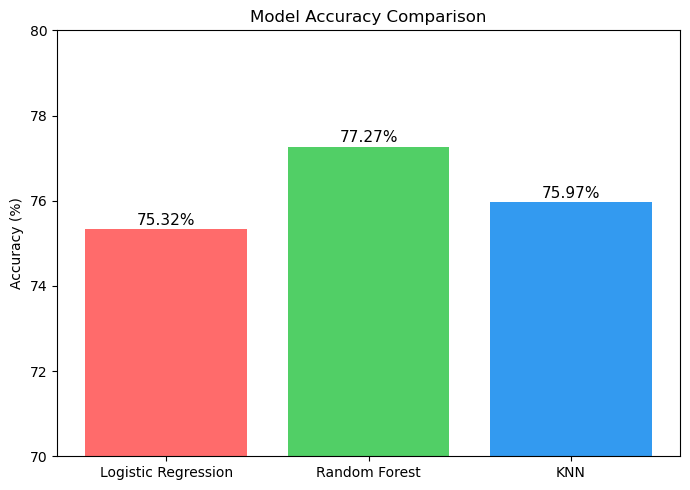

In [13]:
# Model names and their accuracies from Phase 4
model_names = list(results.keys())
accuracies = list(results.values())

# Plot
plt.figure(figsize=(7, 5))
bars = plt.bar(model_names, accuracies, 
               color=['#ff6b6b', '#51cf66', '#339af0'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim([70, 80])

# Add accuracy numbers on top of each bar
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.1,
             f'{acc:.2f}%', 
             ha='center', fontsize=11)

plt.tight_layout()
plt.show()

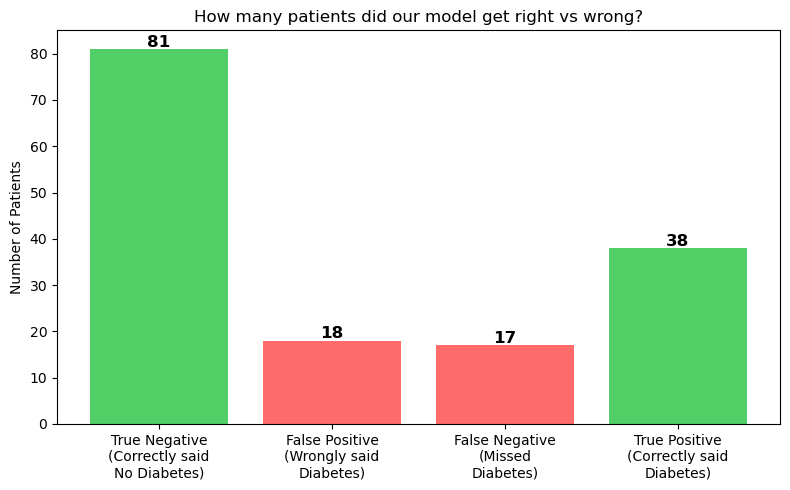

In [14]:
from sklearn.metrics import confusion_matrix

# Get confusion matrix values
cm = confusion_matrix(y_test, y_pred)

# Label them clearly
labels = ['True Negative\n(Correctly said\nNo Diabetes)',
          'False Positive\n(Wrongly said\nDiabetes)',
          'False Negative\n(Missed\nDiabetes)',
          'True Positive\n(Correctly said\nDiabetes)']

values = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
colors = ['#51cf66', '#ff6b6b', '#ff6b6b', '#51cf66']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=colors)

# Add numbers on top
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             str(val),
             ha='center', fontsize=12, fontweight='bold')

plt.title('How many patients did our model get right vs wrong?')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()


In [15]:
import pickle

# Save the model
with open('diabetes_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save the scaler too
with open('diabetes_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
